<a href="https://colab.research.google.com/github/Sanjana6653/DataScience-Tasks/blob/main/Task_Ecommerce.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Analysing Ecommerce sales drop

Company Scenario (Flipkart/amazon) :

we are seeing a drop in revenue find the reason and suggest actions


In [1]:
# import necessary modules

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**MERGING DATASETS**

In [3]:
# load the data
customers = pd.read_csv("customers.csv")
orders = pd.read_csv("orders.csv")
products = pd.read_csv("products.csv")

In [4]:
# Merging orders and customers
df=pd.merge(customers,orders,on="customer_id",how="inner")
df


,customer_id,customer_name,signup_date,order_id,product_id,order_date,city,quantity
0,101,Ravi,2023-11-10,1,201,2024-01-05,Hyderabad,1
1,101,Ravi,2023-11-10,4,202,2024-02-12,Hyderabad,1
2,101,Ravi,2023-11-10,11,201,2024-05-05,Hyderabad,1
3,102,Sneha,2023-12-01,2,202,2024-01-06,Bangalore,2
4,102,Sneha,2023-12-01,7,203,2024-03-15,Bangalore,1
5,103,Amit,2023-12-15,3,203,2024-01-10,Chennai,1
6,103,Amit,2023-12-15,12,205,2024-05-09,Chennai,1
7,104,Pooja,2024-01-05,5,204,2024-02-18,Bangalore,3
8,104,Pooja,2024-01-05,13,202,2024-05-15,Bangalore,1
9,105,Kiran,2024-01-20,6,201,2024-03-05,Chennai,1


In [5]:
# Merging products and customers
df=pd.merge(df,products,on="product_id",how="inner")
df

,customer_id,customer_name,signup_date,order_id,product_id,order_date,city,quantity,product_name,category,price
0,101,Ravi,2023-11-10,1,201,2024-01-05,Hyderabad,1,Laptop,Electronics,70000
1,101,Ravi,2023-11-10,4,202,2024-02-12,Hyderabad,1,Mobile,Electronics,20000
2,101,Ravi,2023-11-10,11,201,2024-05-05,Hyderabad,1,Laptop,Electronics,70000
3,102,Sneha,2023-12-01,2,202,2024-01-06,Bangalore,2,Mobile,Electronics,20000
4,102,Sneha,2023-12-01,7,203,2024-03-15,Bangalore,1,Tablet,Electronics,15000
5,103,Amit,2023-12-15,3,203,2024-01-10,Chennai,1,Tablet,Electronics,15000
6,103,Amit,2023-12-15,12,205,2024-05-09,Chennai,1,Watch,Fashion,5000
7,104,Pooja,2024-01-05,5,204,2024-02-18,Bangalore,3,Shoes,Fashion,3000
8,104,Pooja,2024-01-05,13,202,2024-05-15,Bangalore,1,Mobile,Electronics,20000
9,105,Kiran,2024-01-20,6,201,2024-03-05,Chennai,1,Laptop,Electronics,70000


**EDA**- ( Exploratory Data Analysis)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customer_id    20 non-null     int64 
 1   customer_name  20 non-null     object
 2   signup_date    20 non-null     object
 3   order_id       20 non-null     int64 
 4   product_id     20 non-null     int64 
 5   order_date     20 non-null     object
 6   city           20 non-null     object
 7   quantity       20 non-null     int64 
 8   product_name   20 non-null     object
 9   category       20 non-null     object
 10  price          20 non-null     int64 
dtypes: int64(5), object(6)
memory usage: 1.8+ KB


In [7]:
#changing data types of date
df["signup_date"]=pd.to_datetime(df["signup_date"])
df["order_date"]=pd.to_datetime(df["order_date"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   customer_id    20 non-null     int64         
 1   customer_name  20 non-null     object        
 2   signup_date    20 non-null     datetime64[ns]
 3   order_id       20 non-null     int64         
 4   product_id     20 non-null     int64         
 5   order_date     20 non-null     datetime64[ns]
 6   city           20 non-null     object        
 7   quantity       20 non-null     int64         
 8   product_name   20 non-null     object        
 9   category       20 non-null     object        
 10  price          20 non-null     int64         
dtypes: datetime64[ns](2), int64(5), object(4)
memory usage: 1.8+ KB


In [8]:
# create revenue column
# formula = price * quantity
df["revenue"]=df["quantity"]*df["price"]
df

,customer_id,customer_name,signup_date,order_id,product_id,order_date,city,quantity,product_name,category,price,revenue
0,101,Ravi,2023-11-10,1,201,2024-01-05,Hyderabad,1,Laptop,Electronics,70000,70000
1,101,Ravi,2023-11-10,4,202,2024-02-12,Hyderabad,1,Mobile,Electronics,20000,20000
2,101,Ravi,2023-11-10,11,201,2024-05-05,Hyderabad,1,Laptop,Electronics,70000,70000
3,102,Sneha,2023-12-01,2,202,2024-01-06,Bangalore,2,Mobile,Electronics,20000,40000
4,102,Sneha,2023-12-01,7,203,2024-03-15,Bangalore,1,Tablet,Electronics,15000,15000
5,103,Amit,2023-12-15,3,203,2024-01-10,Chennai,1,Tablet,Electronics,15000,15000
6,103,Amit,2023-12-15,12,205,2024-05-09,Chennai,1,Watch,Fashion,5000,5000
7,104,Pooja,2024-01-05,5,204,2024-02-18,Bangalore,3,Shoes,Fashion,3000,9000
8,104,Pooja,2024-01-05,13,202,2024-05-15,Bangalore,1,Mobile,Electronics,20000,20000
9,105,Kiran,2024-01-20,6,201,2024-03-05,Chennai,1,Laptop,Electronics,70000,70000


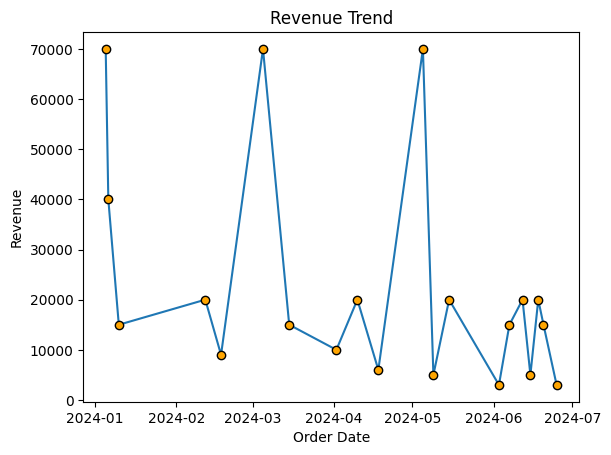

In [9]:
# find the revenue trend
revenue = df.groupby("order_date")["revenue"].sum()
revenue = pd.DataFrame(revenue).reset_index()
plt.plot(revenue["order_date"],revenue["revenue"],marker="o",mfc="orange",mec="black")
plt.xlabel("Order Date")
plt.ylabel("Revenue")
plt.title("Revenue Trend")
plt.show()


The revnue is very less in the last two months **( June , July )**

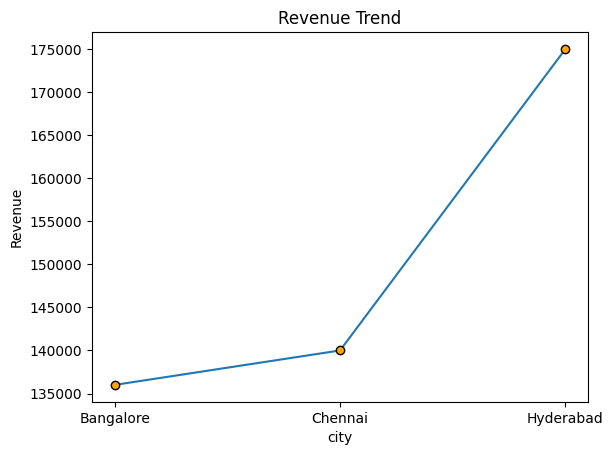

In [10]:
# find the revenue trend  by city
revenue = df.groupby("city")["revenue"].sum()
revenue = pd.DataFrame(revenue).reset_index()
plt.plot(revenue["city"],revenue["revenue"],marker="o",mfc="orange",mec="black")
plt.xlabel("city")
plt.ylabel("Revenue")
plt.title("Revenue Trend")
plt.show()

**Revenue is dropping in bangalore**


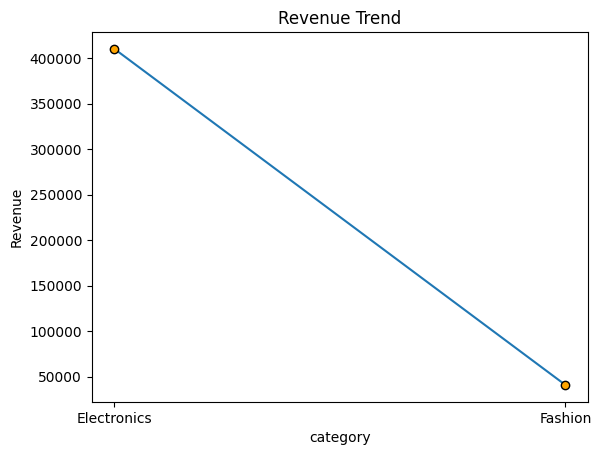

In [11]:
# find the revenue trend  by category
revenue = df.groupby("category")["revenue"].sum()
revenue = pd.DataFrame(revenue).reset_index()
plt.plot(revenue["category"],revenue["revenue"],marker="o",mfc="orange",mec="black")
plt.xlabel("category")
plt.ylabel("Revenue")
plt.title("Revenue Trend")
plt.show()

In Fashion category revenue is droppped


In [12]:
# ciount customers based on order id
df.groupby("customer_id")["order_id"].count()

,order_id
customer_id,
101,3
102,2
103,2
104,2
105,1
106,1
107,1
108,1
109,1


**Most of the customers are ordering less**

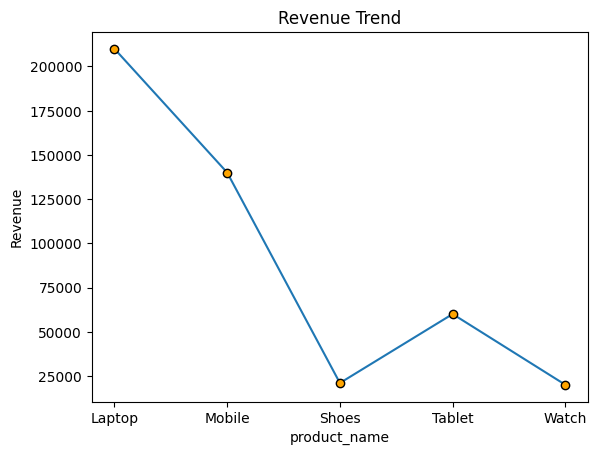

In [13]:
# find the revenue trend  by product name
revenue = df.groupby("product_name")["revenue"].sum()
revenue = pd.DataFrame(revenue).reset_index()
plt.plot(revenue["product_name"],revenue["revenue"],marker="o",mfc="orange",mec="black")
plt.xlabel("product_name")
plt.ylabel("Revenue")
plt.title("Revenue Trend")
plt.show()

**Revenue is very less for shoes and watch**

**Insights:**
1. Revenue got dropped in the last two months (June,July)
2. Banglore contributed more in revenue
3. Fashin Category recorded less revenue
4. Repeatedc customers ordered less
5. Shoes and Watch sales declined significantly                   


**Recommendations**
1. Marketing should be done in Bangalore
2. Provide discounts for shoe and watch
3. Coupens , discounts , loyality programs for pepeated customers

